# Market Context & Regime Analysis

High-level market overview for a recorded period.  
Goal: build intuition about the market regime — activity, spread, depth, volatility, and how the research dataset behaves within that context.

**Data sources:**
- **Raw data** (recorded parquet): book-state metrics via lightweight OrderBook replay + trade-driven metrics from parsed trade events.
- **Built dataset** (ML parquet): feature/label distributions, hourly breakdowns, feature–label relationships.

Both are optional — the notebook runs whichever sections have data available.

## A. Configuration

In [21]:
from pathlib import Path

# --- Paths (set to None to skip that data source) ---
RAW_DATA_PATH = Path("../data/raw/binance/BTCUSDT_v2")   # directory with *.parquet
DATASET_PATH  = Path("../data/datasets/binance/BTCUSDT_v2/dataset_v1.parquet")  # built ML dataset

# --- Symbol ---
SYMBOL = "BTCUSDT"

# --- Replay / dataset params (for interpretation, not computation) ---
INTERVAL_MS = 100       # sampling grid interval
HORIZON_MS  = 200       # label lookahead horizon

# --- Book replay settings ---
BOOK_SAMPLE_MS = 1000   # how often to sample book state (ms)
MAX_RAW_FILES  = None   # limit raw files for speed (None = all)

# --- Raw event loading ---
SAMPLE_EVERY = 1        # load every Nth raw file for trade stats (1 = all)

# --- Display ---
TIMEZONE = "UTC"                # timezone for hour_of_day aggregation
PLOT_RESAMPLE = "5min"          # resample rule for time-series plots
RV_WINDOW     = "5min"          # realized volatility bucket size

# --- Output ---
SAVE_OUTPUTS = True
OUTPUT_DIR   = Path(f"../reports/market_context/{SYMBOL}/run_01")

In [22]:
import json, warnings
from datetime import timezone as _tz
from zoneinfo import ZoneInfo

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import pandas as pd

from src.config.config import fetch_symbol_config
from src.analysis.market_context import (
    load_raw_events, parse_trades,
    replay_book_samples, load_dataset_with_meta,
)

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.float_format", "{:.6f}".format)
%matplotlib inline
plt.rcParams["figure.dpi"] = 100

cfg = fetch_symbol_config(SYMBOL)
tick_size = float(cfg.tick_size)
step_size = float(cfg.step_size)
print(f"Symbol: {SYMBOL}  tick_size={cfg.tick_size}  step_size={cfg.step_size}")

HAS_RAW = RAW_DATA_PATH is not None and Path(RAW_DATA_PATH).exists()
HAS_DS  = DATASET_PATH is not None and Path(DATASET_PATH).exists()
print(f"Raw data available: {HAS_RAW}")
print(f"Dataset available:  {HAS_DS}")

if SAVE_OUTPUTS:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    print(f"Outputs will be saved to {OUTPUT_DIR}")

# --- Plotting helpers ---
_PLOT_TZ = ZoneInfo(TIMEZONE)
_DATE_FMT = mdates.DateFormatter("%H:%M", tz=_PLOT_TZ)

def _fmt_xaxis(ax):
    """Apply consistent timezone-aware time formatting to x-axis."""
    ax.xaxis.set_major_formatter(_DATE_FMT)
    ax.set_xlabel(f"time ({TIMEZONE})")

def _save_fig(fig, name):
    if SAVE_OUTPUTS:
        fig.savefig(OUTPUT_DIR / f"{name}.png", bbox_inches="tight", dpi=150)

def _save_csv(df, name):
    if SAVE_OUTPUTS:
        df.to_csv(OUTPUT_DIR / f"{name}.csv")

def _qrange(s, lo_q=0.01, hi_q=0.99):
    """Quantile clip range + label for plot titles. Returns (lo, hi, tag)."""
    lo = s.quantile(lo_q) if lo_q > 0 else 0
    hi = s.quantile(hi_q)
    lo_s = f"p{lo_q * 100:g}" if lo_q > 0 else "0"
    tag = f"{lo_s}–p{hi_q * 100:g}"
    return lo, hi, tag

Symbol: BTCUSDT  tick_size=0.01  step_size=0.00001
Raw data available: True
Dataset available:  True
Outputs will be saved to ../reports/market_context/BTCUSDT/run_01


## B. Load data

In [23]:
# --- Raw events & trades ---
raw_df = None
trades = None
book_df = None

if HAS_RAW:
    raw_df = load_raw_events(RAW_DATA_PATH, sample_every=SAMPLE_EVERY)
    trades = parse_trades(raw_df)
    print(f"Raw events: {len(raw_df):,}  |  Trades: {len(trades):,}")
    print(f"Time span: {raw_df.datetime.min()} — {raw_df.datetime.max()}")
    print(f"\nEvent type counts:")
    print(raw_df.event_type.value_counts().to_string())
else:
    print("No raw data — skipping raw-data sections.")

Loading raw files: 100%|██████████| 16145/16145 [00:13<00:00, 1232.81it/s]


Raw events: 8,793,735  |  Trades: 7,166,719
Time span: 2026-03-23 20:27:34.402000+00:00 — 2026-03-25 17:58:17.929000+00:00

Event type counts:
event_type
trade            7166719
depthUpdate      1627011
depthSnapshot          5


In [24]:
# --- Lightweight book replay (midprice, spread, depth) ---
if HAS_RAW:
    print(f"Running book replay (sample every {BOOK_SAMPLE_MS}ms, max_files={MAX_RAW_FILES}) ...")
    book_df = replay_book_samples(
        RAW_DATA_PATH, cfg,
        sample_ms=BOOK_SAMPLE_MS,
        max_files=MAX_RAW_FILES,
    )
    # Derived columns
    book_df["spread_usd"] = book_df["spread_ticks"] * tick_size
    book_df["bid_depth"] = book_df["bid_depth_lots"] * step_size  # base asset units
    book_df["ask_depth"] = book_df["ask_depth_lots"] * step_size
    book_df["top_depth"] = book_df["bid_depth"] + book_df["ask_depth"]
    # Log returns within each segment only — NaN at segment boundaries
    book_df["log_return"] = book_df.groupby("segment_id")["midprice"].transform(
        lambda s: np.log(s / s.shift(1))
    )
    n_seg = book_df["segment_id"].nunique()
    print(f"Book samples: {len(book_df):,}  |  Segments: {n_seg}")
    print(f"Time span: {book_df.datetime.min()} — {book_df.datetime.max()}")
else:
    print("No raw data — skipping book replay.")

Running book replay (sample every 1000ms, max_files=None) ...


Book replay: 100%|██████████| 16148/16148 [01:59<00:00, 135.43it/s]


Book samples: 162,766  |  Segments: 5
Time span: 2026-03-23 20:27:35+00:00 — 2026-03-25 17:58:48+00:00


In [25]:
# --- Built dataset ---
ds = None
ds_meta = None

if HAS_DS:
    ds, ds_meta = load_dataset_with_meta(DATASET_PATH)
    print(f"Dataset: {len(ds):,} rows")
    print(f"Time span: {ds.datetime.min()} — {ds.datetime.max()}")
    print(f"\nMetadata:")
    for k, v in sorted(ds_meta.items()):
        print(f"  {k}: {v}")
else:
    print("No dataset — skipping dataset sections.")

Dataset: 1,414,269 rows
Time span: 2026-03-23 20:37:35.300000+00:00 — 2026-03-25 12:53:13.800000+00:00

Metadata:
  bootstrap_count: 5
  data_path: data/raw/binance/BTCUSDT_v2
  horizon_ms: 200
  interval_ms: 100
  rows_dropped_missing_required: 0
  rows_kept: 1414269
  rows_seen: 1414269
  sequence_gaps: 0
  step_size: 0.00001
  symbol: BTCUSDT
  tick_size: 0.01
  trade_window_ms: 1000
  warmup_s: 600


---
## C. Market Overview (from raw data)

Book-state metrics (midprice, spread, depth) come from the lightweight OrderBook replay.  
Trade-driven metrics (count, volume, notional) come from parsed trade events.  
All plots resampled to `PLOT_RESAMPLE` for readability.

**Segment handling:** the book replay tracks discontinuities (re-bootstraps) via `segment_id`.
Log returns are NaN at segment boundaries, so cumulative return resets at each new segment
and realized volatility is never computed across discontinuities.

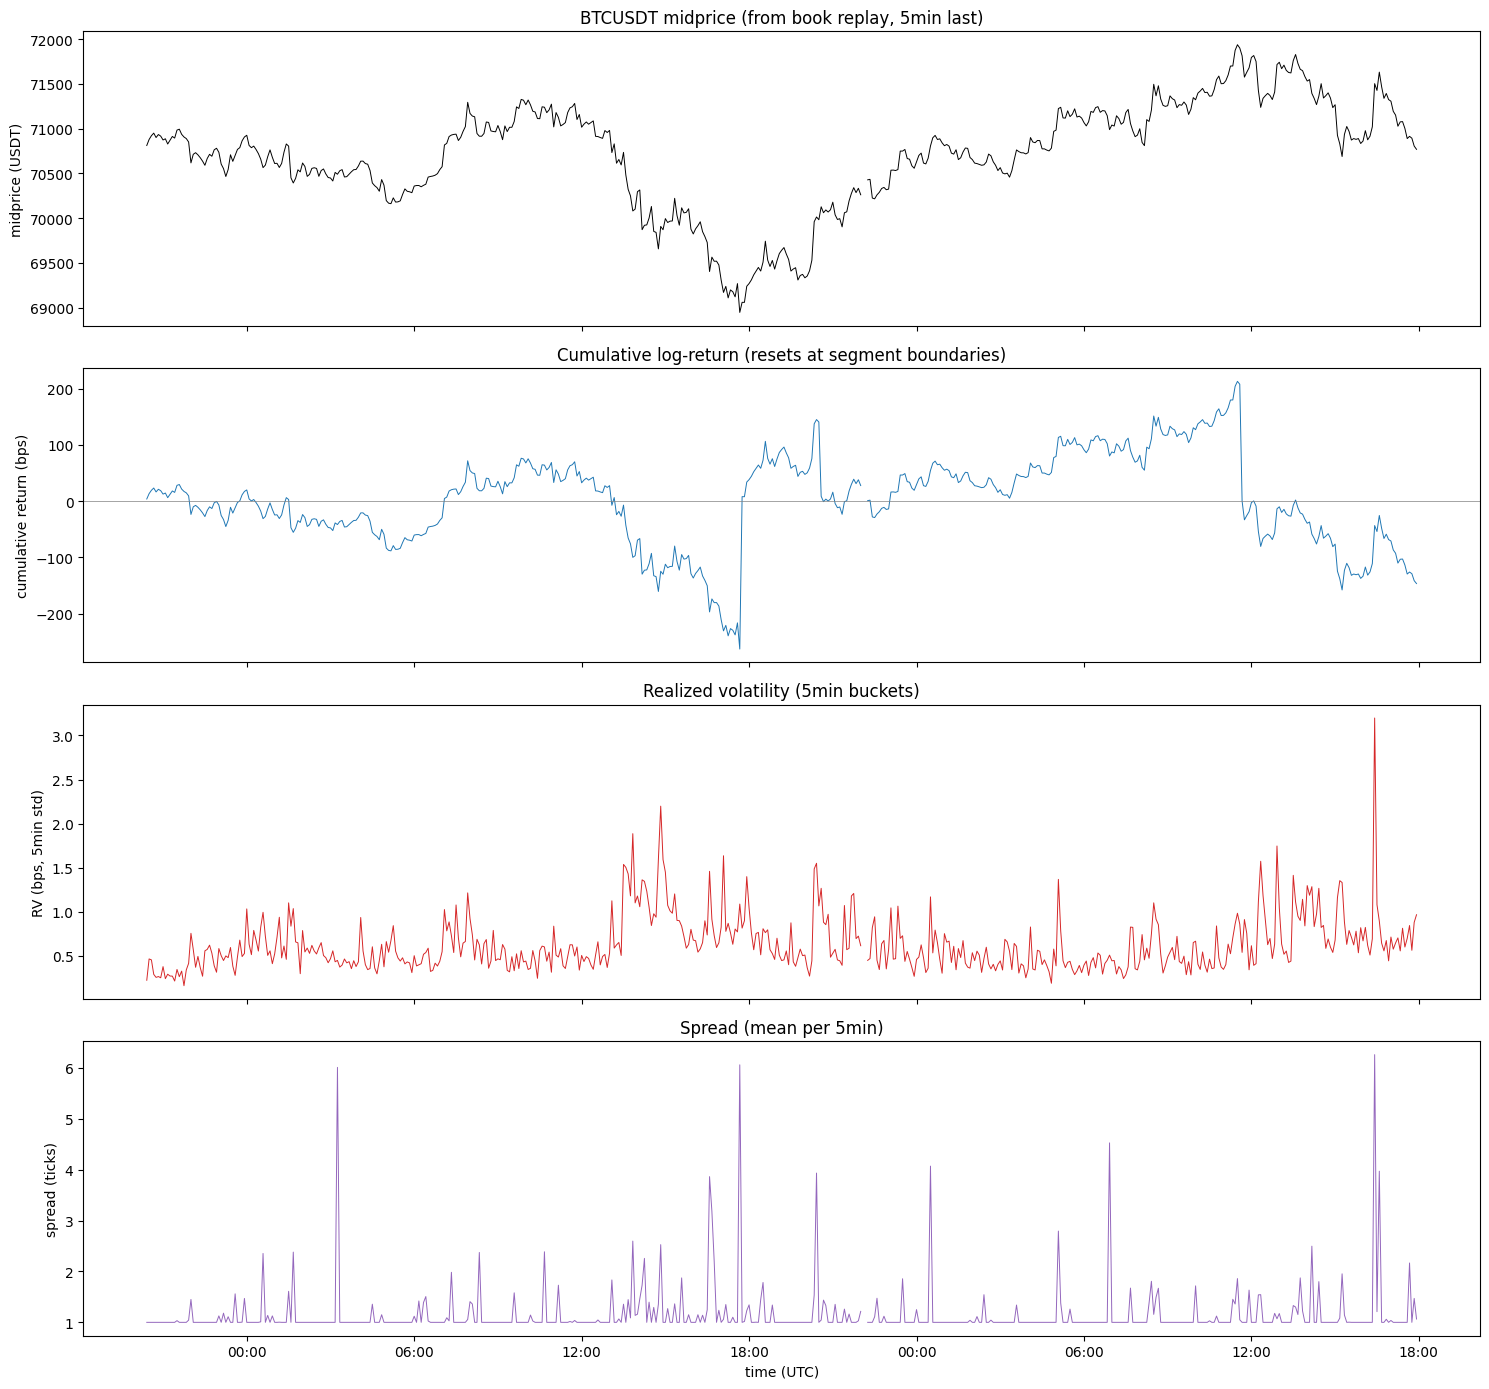

In [26]:
if book_df is None or book_df.empty:
    print("No book data — skipping market overview.")
else:
    bk = book_df.set_index("datetime")

    fig, axes = plt.subplots(4, 1, figsize=(15, 14), sharex=True)

    # 1. Midprice
    ax = axes[0]
    mid_rs = bk["midprice"].resample(PLOT_RESAMPLE).last()
    ax.plot(mid_rs.index, mid_rs, linewidth=0.7, color="black")
    ax.set_ylabel("midprice (USDT)")
    ax.set_title(f"{SYMBOL} midprice (from book replay, {PLOT_RESAMPLE} last)")

    # 2. Cumulative return — resets at segment boundaries
    ax = axes[1]
    cum_ret = book_df.groupby("segment_id")["log_return"].cumsum() * 1e4  # bps
    cum_rs = cum_ret.set_axis(book_df["datetime"]).resample(PLOT_RESAMPLE).last()
    ax.plot(cum_rs.index, cum_rs, linewidth=0.7, color="tab:blue")
    ax.axhline(0, color="gray", linewidth=0.5)
    ax.set_ylabel("cumulative return (bps)")
    ax.set_title("Cumulative log-return (resets at segment boundaries)")

    # 3. Realized volatility — within-segment returns only (NaN at boundaries already)
    ax = axes[2]
    rv = bk["log_return"].resample(RV_WINDOW).std() * 1e4  # bps
    ax.plot(rv.index, rv, linewidth=0.7, color="tab:red")
    ax.set_ylabel(f"RV (bps, {RV_WINDOW} std)")
    ax.set_title(f"Realized volatility ({RV_WINDOW} buckets)")

    # 4. Spread
    ax = axes[3]
    sp_rs = bk["spread_ticks"].resample(PLOT_RESAMPLE).mean()
    ax.plot(sp_rs.index, sp_rs, linewidth=0.7, color="tab:purple")
    ax.set_ylabel("spread (ticks)")
    ax.set_title(f"Spread (mean per {PLOT_RESAMPLE})")

    _fmt_xaxis(axes[-1])
    fig.tight_layout()
    _save_fig(fig, "overview_book_1")
    plt.show()

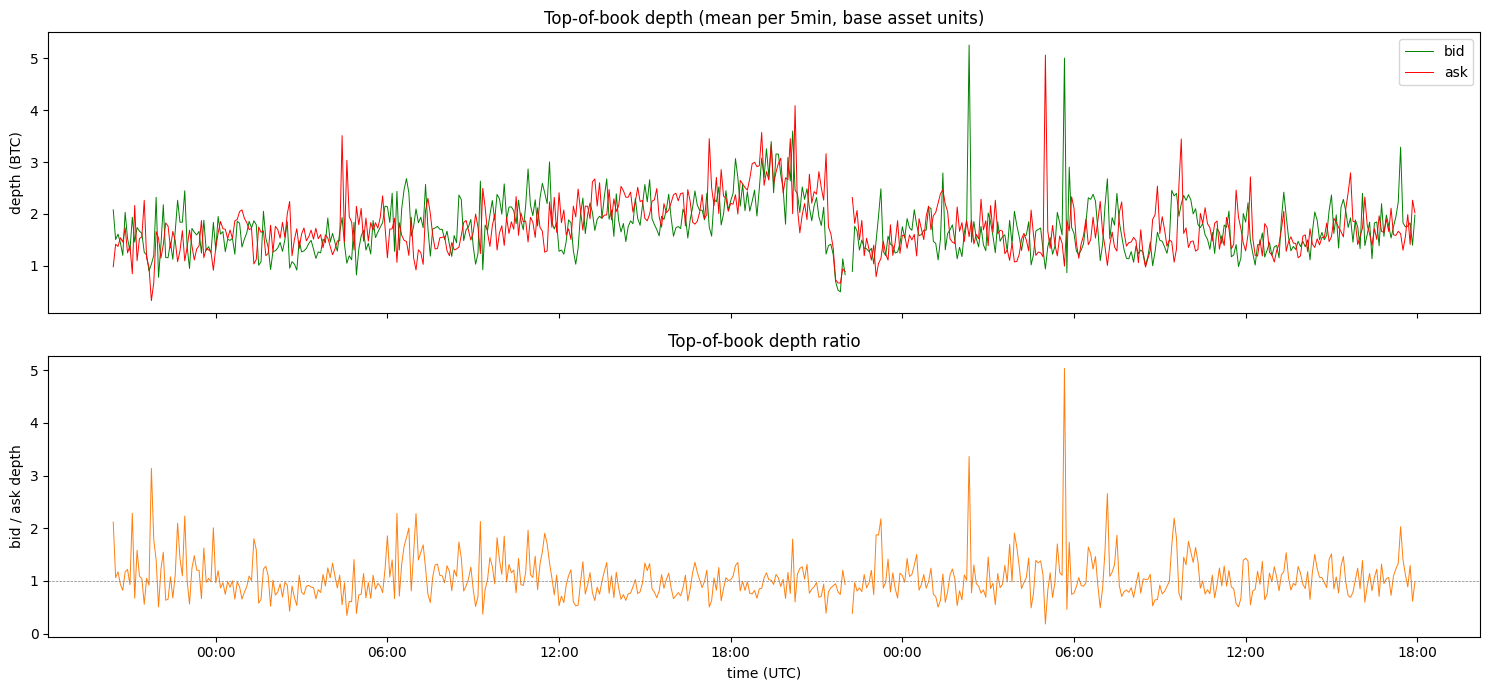

In [27]:
if book_df is not None and not book_df.empty:
    bk = book_df.set_index("datetime")

    fig, axes = plt.subplots(2, 1, figsize=(15, 7), sharex=True)

    # 5. Top-of-book depth
    ax = axes[0]
    bid_rs = bk["bid_depth"].resample(PLOT_RESAMPLE).mean()
    ask_rs = bk["ask_depth"].resample(PLOT_RESAMPLE).mean()
    ax.plot(bid_rs.index, bid_rs, linewidth=0.7, color="green", label="bid")
    ax.plot(ask_rs.index, ask_rs, linewidth=0.7, color="red", label="ask")
    ax.set_ylabel(f"depth ({SYMBOL[:3]})")
    ax.set_title(f"Top-of-book depth (mean per {PLOT_RESAMPLE}, base asset units)")
    ax.legend()

    # 6. Bid/ask depth ratio
    ax = axes[1]
    ratio_rs = (bid_rs / ask_rs).replace([np.inf, -np.inf], np.nan)
    ax.plot(ratio_rs.index, ratio_rs, linewidth=0.7, color="tab:orange")
    ax.axhline(1.0, color="gray", linewidth=0.5, ls="--")
    ax.set_ylabel("bid / ask depth")
    ax.set_title("Top-of-book depth ratio")

    _fmt_xaxis(axes[-1])
    fig.tight_layout()
    _save_fig(fig, "overview_book_2")
    plt.show()

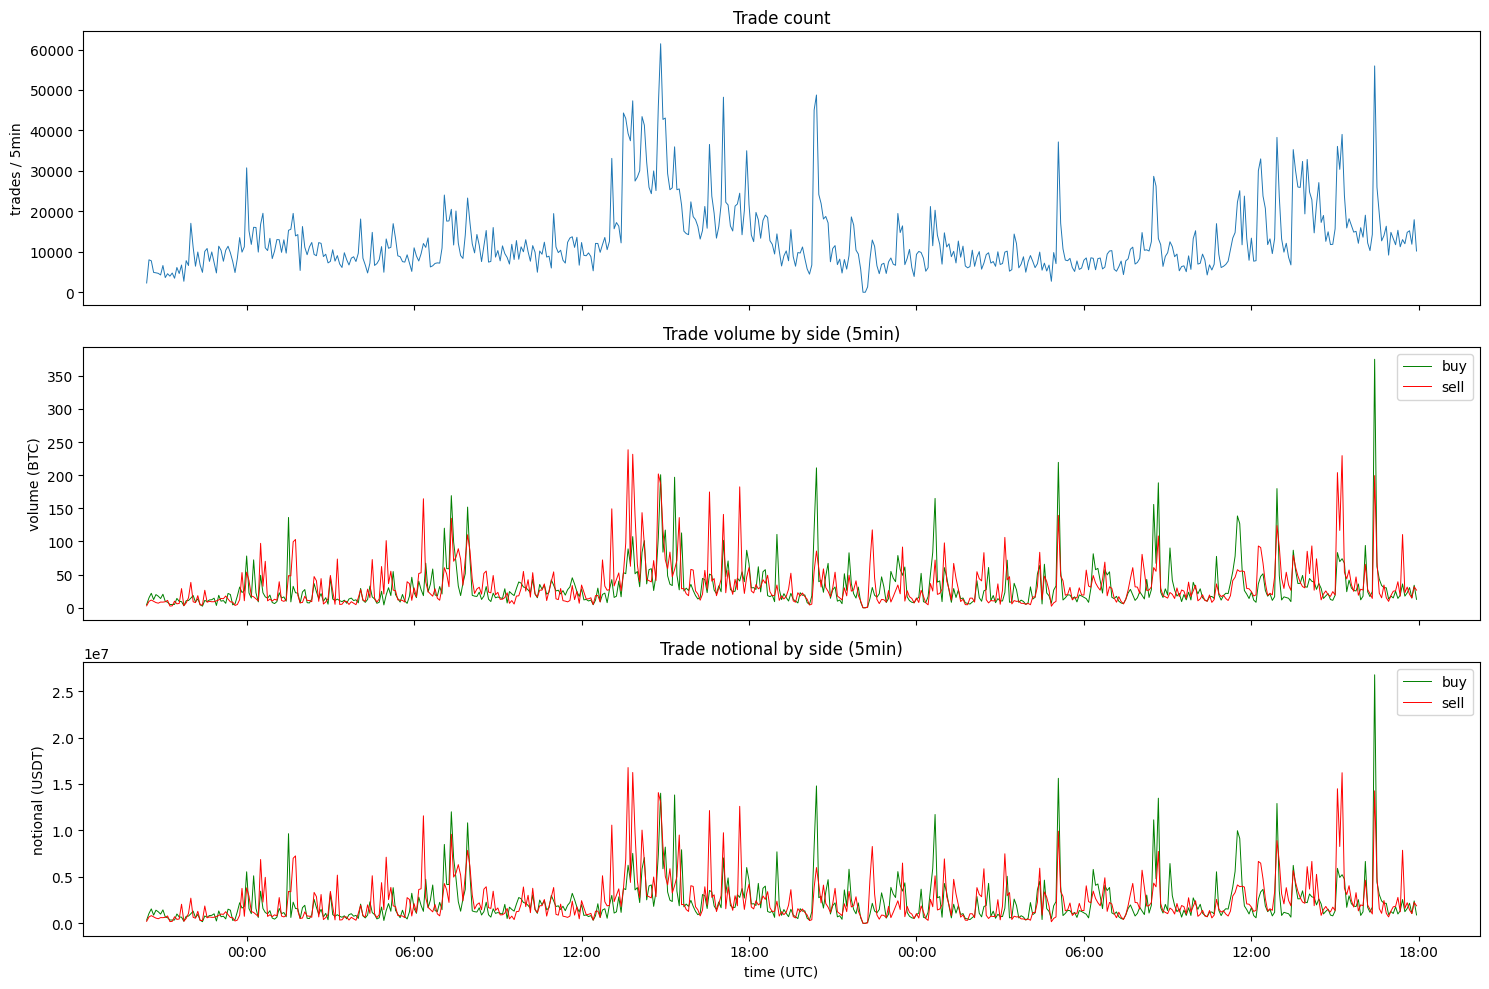

In [28]:
# --- Trade-driven metrics ---
if trades is None or trades.empty:
    print("No trade data — skipping trade plots.")
else:
    tr = trades.set_index("datetime")

    fig, axes = plt.subplots(3, 1, figsize=(15, 10), sharex=True)

    # 7. Trade count
    ax = axes[0]
    tc = tr["price"].resample(PLOT_RESAMPLE).count()
    ax.plot(tc.index, tc, linewidth=0.7, color="tab:blue")
    ax.set_ylabel(f"trades / {PLOT_RESAMPLE}")
    ax.set_title("Trade count")

    # 8. Trade volume (base asset)
    ax = axes[1]
    buy_vol = tr.loc[tr.side == "buy", "qty"].resample(PLOT_RESAMPLE).sum().fillna(0)
    sell_vol = tr.loc[tr.side == "sell", "qty"].resample(PLOT_RESAMPLE).sum().fillna(0)
    ax.plot(buy_vol.index, buy_vol, linewidth=0.7, color="green", label="buy")
    ax.plot(sell_vol.index, sell_vol, linewidth=0.7, color="red", label="sell")
    ax.set_ylabel(f"volume ({SYMBOL[:3]})")
    ax.set_title(f"Trade volume by side ({PLOT_RESAMPLE})")
    ax.legend()

    # 9. Trade notional (USDT)
    ax = axes[2]
    buy_not = tr.loc[tr.side == "buy", "notional"].resample(PLOT_RESAMPLE).sum().fillna(0)
    sell_not = tr.loc[tr.side == "sell", "notional"].resample(PLOT_RESAMPLE).sum().fillna(0)
    ax.plot(buy_not.index, buy_not, linewidth=0.7, color="green", label="buy")
    ax.plot(sell_not.index, sell_not, linewidth=0.7, color="red", label="sell")
    ax.set_ylabel("notional (USDT)")
    ax.set_title(f"Trade notional by side ({PLOT_RESAMPLE})")
    ax.legend()

    _fmt_xaxis(axes[-1])
    fig.tight_layout()
    _save_fig(fig, "overview_trades")
    plt.show()

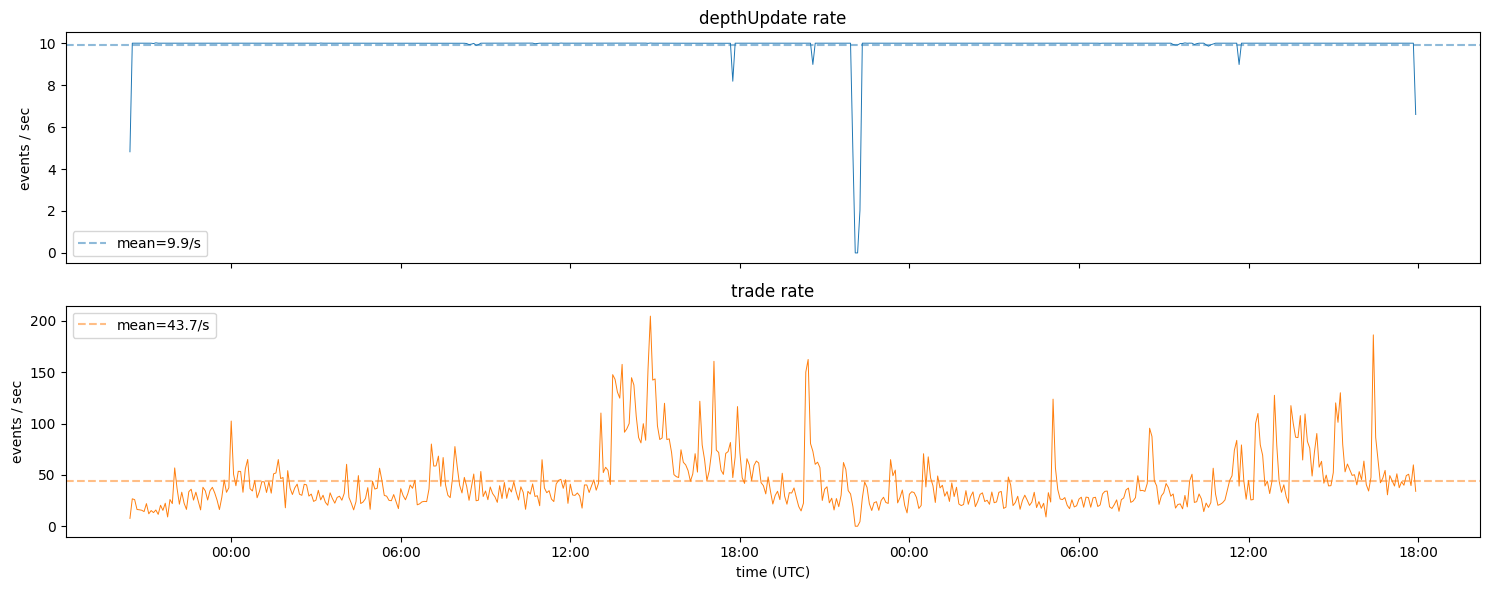

In [29]:
# --- Event rate over time ---
if raw_df is not None:
    ev = raw_df.set_index("datetime")

    fig, axes = plt.subplots(2, 1, figsize=(15, 6), sharex=True)

    for ax, etype, color in [
        (axes[0], "depthUpdate", "tab:blue"),
        (axes[1], "trade", "tab:orange"),
    ]:
        rate = ev[ev.event_type == etype]["recv_ts"].resample(PLOT_RESAMPLE).count()
        bucket_s = pd.Timedelta(PLOT_RESAMPLE).total_seconds()
        rate_per_s = rate / bucket_s
        ax.plot(rate_per_s.index, rate_per_s, linewidth=0.7, color=color)
        ax.axhline(rate_per_s.mean(), ls="--", color=color, alpha=0.5,
                   label=f"mean={rate_per_s.mean():.1f}/s")
        ax.set_ylabel("events / sec")
        ax.set_title(f"{etype} rate")
        ax.legend()

    _fmt_xaxis(axes[-1])
    fig.tight_layout()
    _save_fig(fig, "event_rates")
    plt.show()

In [30]:
# --- Summary table ---
summary_rows = {}
if book_df is not None and not book_df.empty:
    summary_rows.update({
        "period_start": str(book_df.datetime.min()),
        "period_end": str(book_df.datetime.max()),
        "duration": str(book_df.datetime.max() - book_df.datetime.min()),
        "segments": str(book_df.segment_id.nunique()),
        "midprice_start (USDT)": f"{book_df.midprice.iloc[0]:.2f}",
        "midprice_end (USDT)": f"{book_df.midprice.iloc[-1]:.2f}",
        "midprice_min (USDT)": f"{book_df.midprice.min():.2f}",
        "midprice_max (USDT)": f"{book_df.midprice.max():.2f}",
        "total_return (bps)": f"{book_df.log_return.sum() * 1e4:.1f}",
        "avg_spread (ticks)": f"{book_df.spread_ticks.mean():.2f}",
        "median_spread (ticks)": f"{book_df.spread_ticks.median():.1f}",
        "pct_1tick_spread": f"{(book_df.spread_ticks == 1).mean():.1%}",
        f"avg_bid_depth ({SYMBOL[:3]})": f"{book_df.bid_depth.mean():.5f}",
        f"avg_ask_depth ({SYMBOL[:3]})": f"{book_df.ask_depth.mean():.5f}",
    })
if trades is not None and not trades.empty:
    dur_s = (trades.datetime.max() - trades.datetime.min()).total_seconds()
    summary_rows.update({
        "total_trades": f"{len(trades):,}",
        "total_volume (base)": f"{trades.qty.sum():.4f}",
        "total_notional (USDT)": f"{trades.notional.sum():,.0f}",
        "avg_trade_size (base)": f"{trades.qty.mean():.6f}",
        "median_trade_notional (USDT)": f"{trades.notional.median():.0f}",
        "trades_per_sec": f"{len(trades) / dur_s:.1f}" if dur_s > 0 else "N/A",
        "buy_pct": f"{(trades.side == 'buy').mean():.1%}",
    })
if raw_df is not None:
    summary_rows["depth_updates"] = f"{(raw_df.event_type == 'depthUpdate').sum():,}"
    summary_rows["total_events"] = f"{len(raw_df):,}"

summary_table = pd.Series(summary_rows, name="value")
summary_table.index.name = "metric"
print("=== Period Summary ===")
print(summary_table.to_string())
_save_csv(summary_table.to_frame(), "summary")

=== Period Summary ===
metric
period_start                    2026-03-23 20:27:35+00:00
period_end                      2026-03-25 17:58:48+00:00
duration                                  1 days 21:31:13
segments                                                5
midprice_start (USDT)                            70784.13
midprice_end (USDT)                              70768.21
midprice_min (USDT)                              68923.07
midprice_max (USDT)                              72026.09
total_return (bps)                                  -29.5
avg_spread (ticks)                                   1.16
median_spread (ticks)                                 1.0
pct_1tick_spread                                    99.9%
avg_bid_depth (BTC)                               1.74819
avg_ask_depth (BTC)                               1.76232
total_trades                                    7,166,719
total_volume (base)                            36316.7017
total_notional (USDT)                     

---
## D. Intraday Seasonality

Aggregate by `hour_of_day` in the configured timezone.  
This reveals when the market is most active, tightest, and most volatile — essential for understanding regime variation and for conditioning signals.

In [31]:
if not HAS_RAW:
    print("No raw data — skipping intraday seasonality.")
else:
    # Add hour column to each source
    def _hour(dt_series):
        return dt_series.dt.tz_convert(TIMEZONE).dt.hour

    trades["hour"] = _hour(trades["datetime"])
    book_df["hour"] = _hour(book_df["datetime"])
    raw_df["hour"] = _hour(raw_df["datetime"])

    # Duration per hour_of_day: count distinct calendar hours observed,
    # then multiply by 3600s.  This avoids the max-min bug where hours
    # appearing on only one day get a tiny denominator.
    raw_df["_cal_hour"] = raw_df["datetime"].dt.tz_convert(TIMEZONE).dt.floor("h")
    n_cal_hours = raw_df.groupby("hour")["_cal_hour"].nunique().rename("n_periods")
    hour_dur = (n_cal_hours * 3600).rename("duration_s")

    # --- Trade stats by hour ---
    tg = trades.groupby("hour")
    trade_hourly = pd.DataFrame({
        "trade_count":    tg["price"].count(),
        "trade_volume":   tg["qty"].sum(),
        "trade_notional": tg["notional"].sum(),
        "avg_trade_size": tg["qty"].mean(),
    })

    # --- Event counts by hour ---
    depth_hourly = raw_df[raw_df.event_type == "depthUpdate"].groupby("hour")["recv_ts"].count().rename("depth_update_count")

    # --- Book stats by hour ---
    bg = book_df.groupby("hour")
    book_hourly = pd.DataFrame({
        "avg_spread (ticks)":    bg["spread_ticks"].mean(),
        "p90_spread (ticks)":    bg["spread_ticks"].quantile(0.9),
        "pct_1tick_spread":      bg["spread_ticks"].apply(lambda x: (x == 1).mean()),
        f"avg_bid_depth ({SYMBOL[:3]})": bg["bid_depth"].mean(),
        f"avg_ask_depth ({SYMBOL[:3]})": bg["ask_depth"].mean(),
        f"avg_top_depth ({SYMBOL[:3]})": bg["top_depth"].mean(),
        "realized_vol (bps)":    bg["log_return"].std() * 1e4,
        "avg_abs_return (bps)":  bg["log_return"].apply(lambda x: x.abs().mean()) * 1e4,
    })

    # --- Combine ---
    hourly_stats = trade_hourly.join(depth_hourly).join(book_hourly)
    hourly_stats["total_events"] = hourly_stats.get("trade_count", 0) + hourly_stats.get("depth_update_count", 0)
    hourly_stats["n_periods"] = n_cal_hours
    hourly_stats["avg_trade_rate (/s)"] = hourly_stats["trade_count"] / hour_dur
    hourly_stats["avg_depth_rate (/s)"] = hourly_stats["depth_update_count"] / hour_dur
    hourly_stats.index.name = "hour_of_day"

    print(f"=== Hourly Stats ({TIMEZONE}) ===")
    with pd.option_context("display.max_columns", 20, "display.width", 200, "display.float_format", "{:.4f}".format):
        print(hourly_stats.to_string())
    _save_csv(hourly_stats, "hourly_stats")

=== Hourly Stats (UTC) ===
             trade_count  trade_volume  trade_notional  avg_trade_size  depth_update_count  avg_spread (ticks)  p90_spread (ticks)  pct_1tick_spread  avg_bid_depth (BTC)  avg_ask_depth (BTC)  avg_top_depth (BTC)  realized_vol (bps)  avg_abs_return (bps)  total_events  n_periods  avg_trade_rate (/s)  avg_depth_rate (/s)
hour_of_day                                                                                                                                                                                                                                                                                                                     
0                 313825     1520.1605  107621675.3854          0.0048               72001              1.2061              1.0000            0.9986               1.6571               1.6882               3.3454              0.6558                0.2514        385826          2              43.5868              10.0001
1         

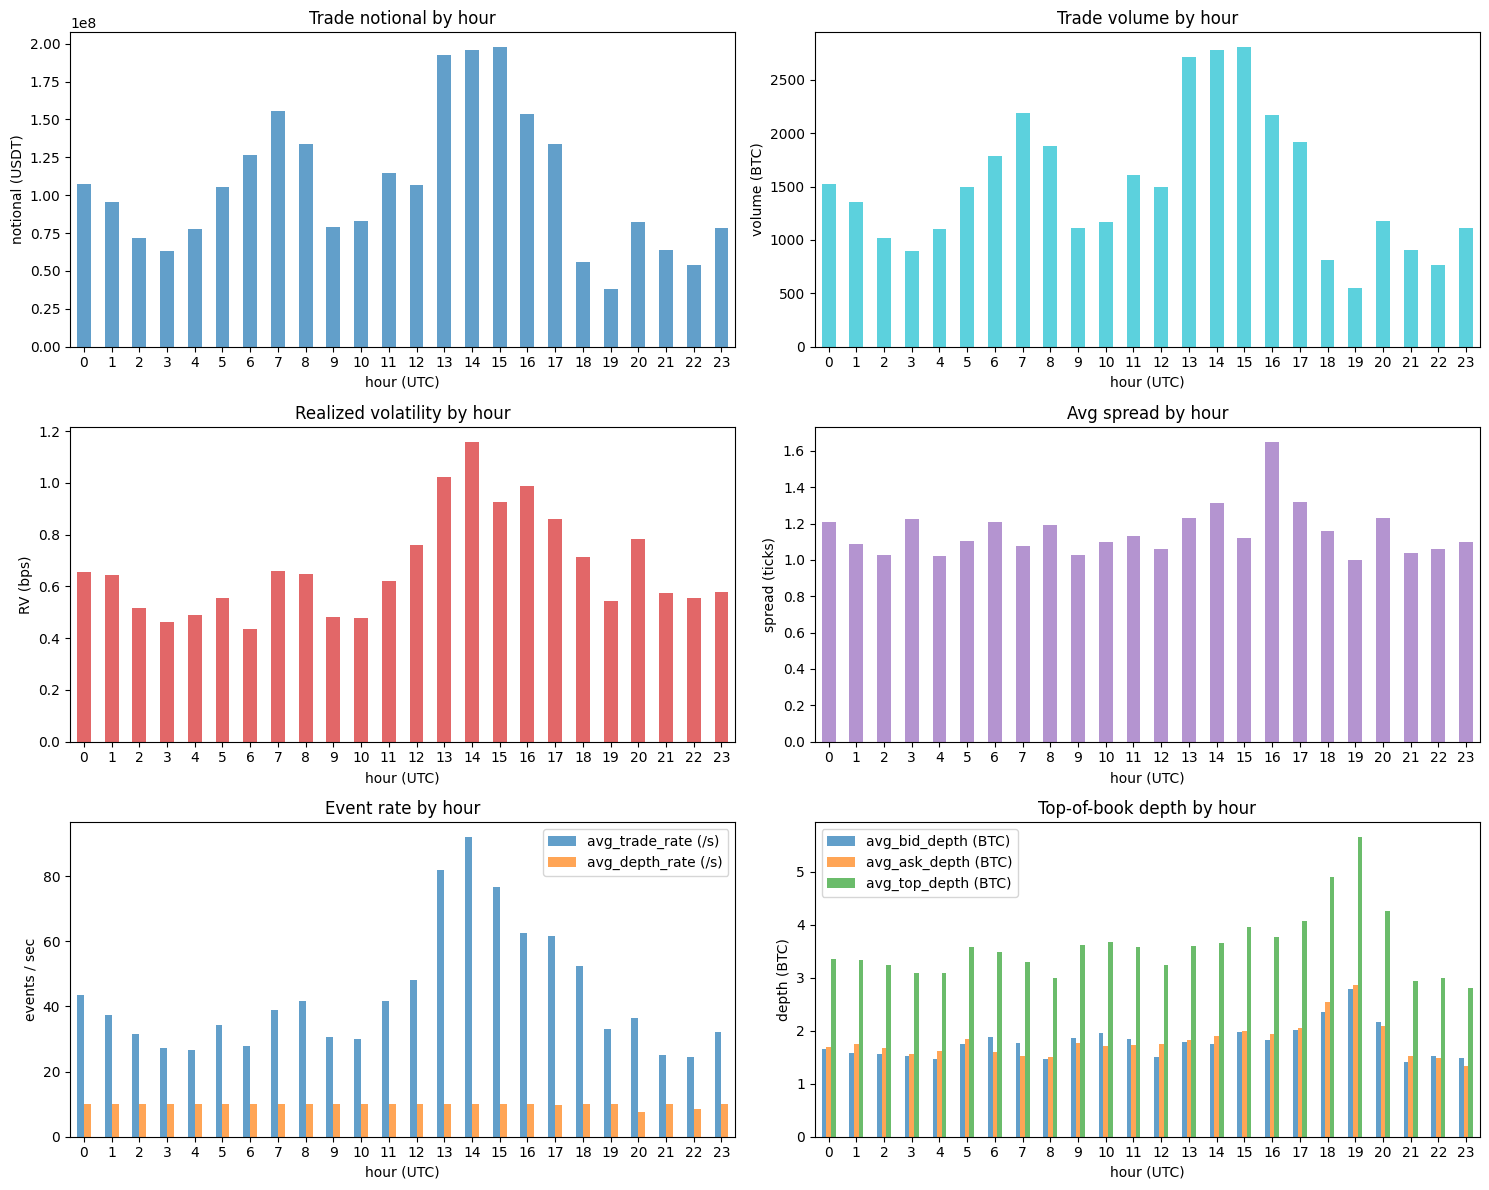

In [32]:
# --- Hourly profile plots ---
if HAS_RAW:
    fig, axes = plt.subplots(3, 2, figsize=(15, 12))

    # Trade notional
    ax = axes[0, 0]
    hourly_stats["trade_notional"].plot.bar(ax=ax, color="tab:blue", alpha=0.7)
    ax.set_ylabel("notional (USDT)")
    ax.set_title("Trade notional by hour")

    # Trade volume
    ax = axes[0, 1]
    hourly_stats["trade_volume"].plot.bar(ax=ax, color="tab:cyan", alpha=0.7)
    ax.set_ylabel(f"volume ({SYMBOL[:3]})")
    ax.set_title("Trade volume by hour")

    # Realized vol
    ax = axes[1, 0]
    hourly_stats["realized_vol (bps)"].plot.bar(ax=ax, color="tab:red", alpha=0.7)
    ax.set_ylabel("RV (bps)")
    ax.set_title("Realized volatility by hour")

    # Spread
    ax = axes[1, 1]
    hourly_stats["avg_spread (ticks)"].plot.bar(ax=ax, color="tab:purple", alpha=0.7)
    ax.set_ylabel("spread (ticks)")
    ax.set_title("Avg spread by hour")

    # Event rates
    ax = axes[2, 0]
    hourly_stats[["avg_trade_rate (/s)", "avg_depth_rate (/s)"]].plot.bar(ax=ax, alpha=0.7)
    ax.set_ylabel("events / sec")
    ax.set_title("Event rate by hour")

    # Top-of-book depth
    ax = axes[2, 1]
    depth_cols = [c for c in hourly_stats.columns if "depth" in c.lower() and "avg" in c.lower() and "rate" not in c.lower() and "update" not in c.lower()]
    hourly_stats[depth_cols].plot.bar(ax=ax, alpha=0.7)
    ax.set_ylabel(f"depth ({SYMBOL[:3]})")
    ax.set_title("Top-of-book depth by hour")

    for ax in axes.flat:
        ax.set_xlabel(f"hour ({TIMEZONE})")
        ax.tick_params(axis="x", rotation=0)
    fig.tight_layout()
    _save_fig(fig, "hourly_profiles")
    plt.show()

---
## E. Distribution / Microstructure Context

General-purpose microstructure views to improve intuition about the market regime.  
Spread and imbalance from the book replay; trade inter-arrival and size from raw trades.

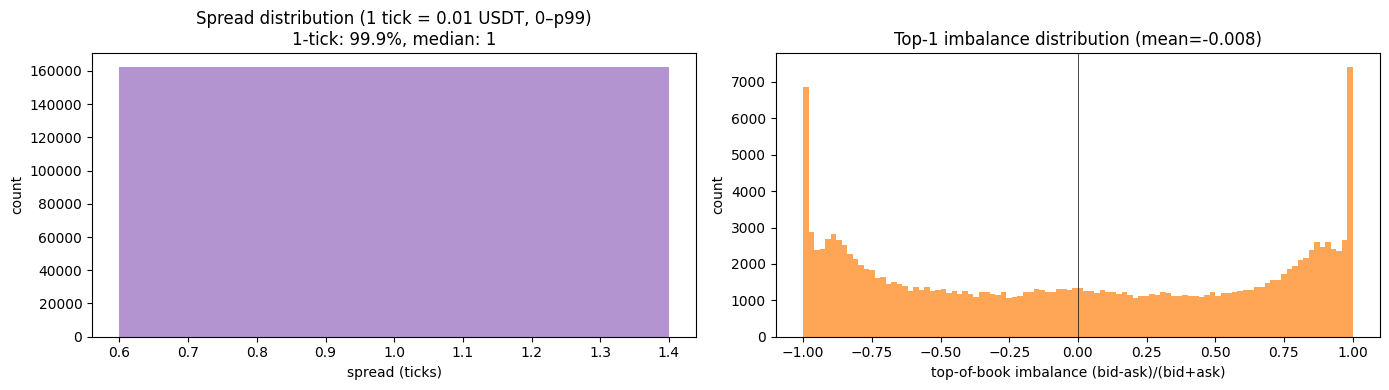

In [33]:
if book_df is not None and not book_df.empty:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    # Spread distribution (ticks)
    ax = axes[0]
    sp = book_df["spread_ticks"]
    _, cutoff, sp_tag = _qrange(sp, 0, 0.99)
    sp_counts = sp.value_counts().sort_index()
    sp_show = sp_counts.loc[:int(cutoff)]
    ax.bar(sp_show.index, sp_show.values, color="tab:purple", alpha=0.7)
    ax.set_xlabel("spread (ticks)")
    ax.set_ylabel("count")
    ax.set_title(f"Spread distribution (1 tick = {tick_size} USDT, {sp_tag})\n"
                 f"1-tick: {(sp == 1).mean():.1%}, median: {sp.median():.0f}")

    # Imbalance distribution (top-1 from book replay)
    ax = axes[1]
    imb = (book_df["bid_depth"] - book_df["ask_depth"]) / book_df["top_depth"].replace(0, np.nan)
    ax.hist(imb.dropna(), bins=100, edgecolor="none", alpha=0.7, color="tab:orange")
    ax.set_xlabel("top-of-book imbalance (bid-ask)/(bid+ask)")
    ax.set_ylabel("count")
    ax.axvline(0, color="black", linewidth=0.5)
    ax.set_title(f"Top-1 imbalance distribution (mean={imb.mean():.3f})")

    fig.tight_layout()
    _save_fig(fig, "microstructure_book")
    plt.show()
else:
    print("No book data — skipping book distributions.")

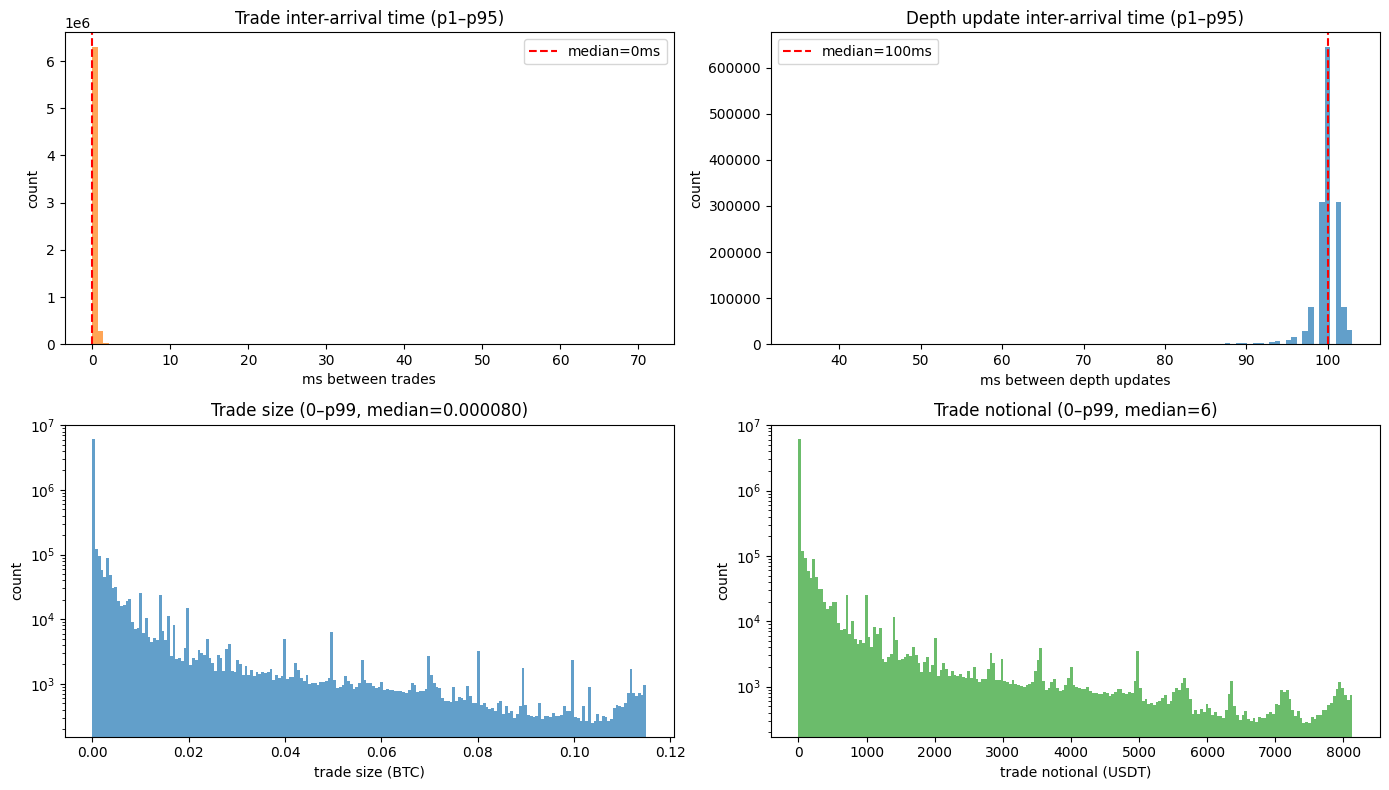

In [34]:
if trades is not None and not trades.empty:
    fig, axes = plt.subplots(2, 2, figsize=(14, 8))

    # Trade inter-arrival time
    ax = axes[0, 0]
    iat_trade = trades["recv_ts"].diff().dropna()
    lo, hi, tag = _qrange(iat_trade, 0.01, 0.95)
    ax.hist(iat_trade, bins=100, range=(lo, hi), edgecolor="none", alpha=0.7, color="tab:orange")
    ax.set_xlabel("ms between trades")
    ax.set_ylabel("count")
    ax.axvline(iat_trade.median(), color="red", ls="--", label=f"median={iat_trade.median():.0f}ms")
    ax.set_title(f"Trade inter-arrival time ({tag})")
    ax.legend()

    # Depth update inter-arrival time
    ax = axes[0, 1]
    if raw_df is not None:
        depth_ts = raw_df.loc[raw_df.event_type == "depthUpdate", "recv_ts"]
        iat_depth = depth_ts.diff().dropna()
        lo, hi, tag = _qrange(iat_depth, 0.01, 0.95)
        ax.hist(iat_depth, bins=100, range=(lo, hi), edgecolor="none", alpha=0.7, color="tab:blue")
        ax.set_xlabel("ms between depth updates")
        ax.set_ylabel("count")
        ax.axvline(iat_depth.median(), color="red", ls="--", label=f"median={iat_depth.median():.0f}ms")
        ax.set_title(f"Depth update inter-arrival time ({tag})")
        ax.legend()

    # Trade size distribution (base asset)
    ax = axes[1, 0]
    q = trades["qty"]
    lo, hi, tag = _qrange(q, 0, 0.99)
    ax.hist(q, bins=200, range=(lo, hi), edgecolor="none", alpha=0.7)
    ax.set_yscale("log")
    ax.set_xlabel(f"trade size ({SYMBOL[:3]})")
    ax.set_ylabel("count")
    ax.set_title(f"Trade size ({tag}, median={q.median():.6f})")

    # Trade notional distribution
    ax = axes[1, 1]
    n = trades["notional"]
    lo, hi, tag = _qrange(n, 0, 0.99)
    ax.hist(n, bins=200, range=(lo, hi), edgecolor="none", alpha=0.7, color="tab:green")
    ax.set_yscale("log")
    ax.set_xlabel("trade notional (USDT)")
    ax.set_ylabel("count")
    ax.set_title(f"Trade notional ({tag}, median={n.median():.0f})")

    fig.tight_layout()
    _save_fig(fig, "microstructure_trades")
    plt.show()
else:
    print("No trade data — skipping trade distributions.")

---
## F. Dataset-Facing Context

How the built ML dataset behaves in the context of the market regime.  
Uses the dataset parquet directly. All units come from the dataset schema:
- `spread`: USDT (convert to ticks via `/ tick_size`)
- `imbalance_*`: dimensionless [-1, 1]
- `microprice_minus_mid`, `delta_midprice`, `label`: USDT
- `buy_volume`, `sell_volume`: base asset

In [35]:
if not HAS_DS:
    print("No dataset — skipping dataset sections.")
else:
    ds_tick = float(ds_meta.get("tick_size", tick_size))

    label = ds["label"]
    zero_pct = (label == 0).mean()
    pos_pct  = (label > 0).mean()
    neg_pct  = (label < 0).mean()
    large_pct = (label.abs() >= ds_tick).mean()

    ds_summary = pd.Series({
        "rows": f"{len(ds):,}",
        "start": str(ds.datetime.min()),
        "end": str(ds.datetime.max()),
        "duration": str(ds.datetime.max() - ds.datetime.min()),
        "interval_ms": ds_meta.get("interval_ms", "?"),
        "horizon_ms": ds_meta.get("horizon_ms", "?"),
        "label_mean (USDT)": f"{label.mean():.6f}",
        "label_std (USDT)": f"{label.std():.4f}",
        "label_zero_pct": f"{zero_pct:.1%}",
        "label_pos_pct": f"{pos_pct:.1%}",
        "label_neg_pct": f"{neg_pct:.1%}",
        f"label_|l|>=1tick ({ds_tick})": f"{large_pct:.1%}",
        "label_nonzero_pct": f"{1 - zero_pct:.1%}",
    }, name="value")
    ds_summary.index.name = "metric"
    print("=== Dataset Summary ===")
    print(ds_summary.to_string())
    _save_csv(ds_summary.to_frame(), "dataset_summary")

=== Dataset Summary ===
metric
rows                                              1,414,269
start                      2026-03-23 20:37:35.300000+00:00
end                        2026-03-25 12:53:13.800000+00:00
duration                             1 days 16:15:38.500000
interval_ms                                             100
horizon_ms                                              200
label_mean (USDT)                                  0.000465
label_std (USDT)                                     1.7752
label_zero_pct                                        92.2%
label_pos_pct                                          3.9%
label_neg_pct                                          4.0%
label_|l|>=1tick (0.01)                                7.8%
label_nonzero_pct                                      7.8%


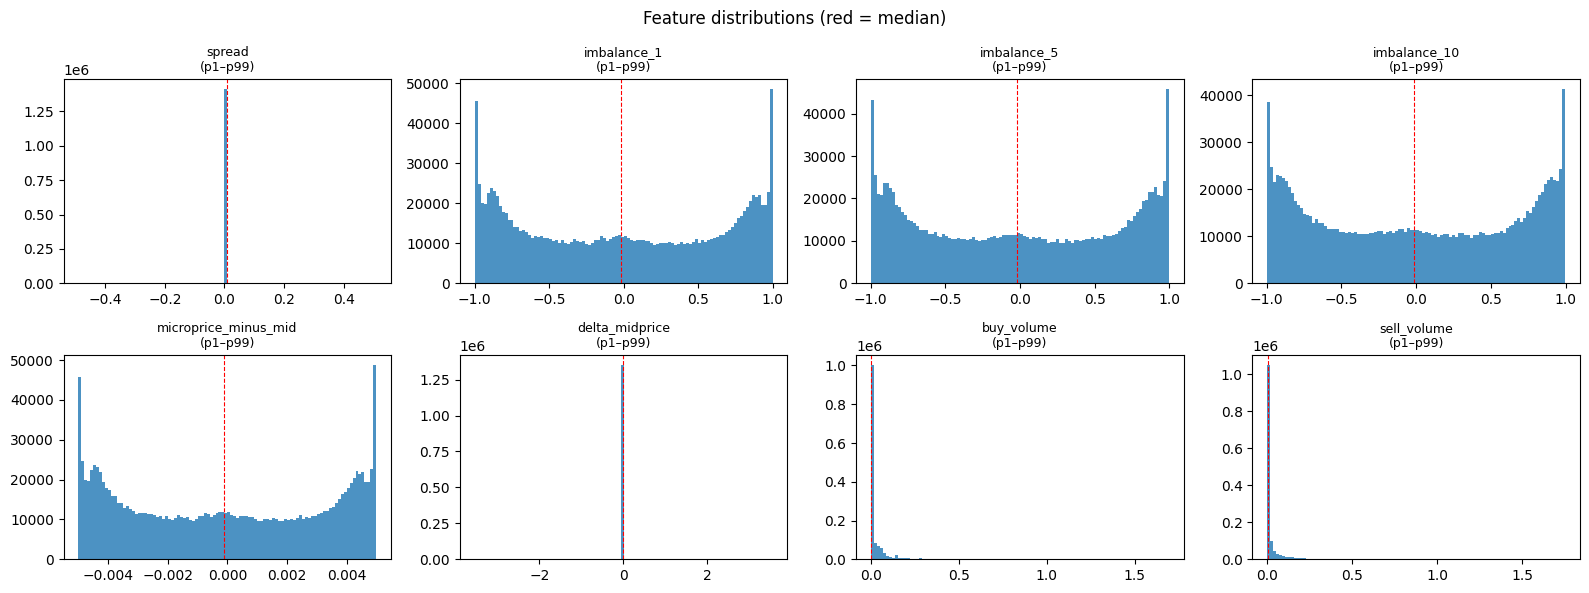

=== Feature Stats ===
              spread    imbalance_1    imbalance_5   imbalance_10  microprice_minus_mid  delta_midprice     buy_volume    sell_volume
count 1414269.000000 1414269.000000 1414269.000000 1414269.000000        1414269.000000  1414269.000000 1414269.000000 1414269.000000
mean        0.011490      -0.008411      -0.008058      -0.005222             -0.000032        0.000229       0.103682       0.109842
std         0.090572       0.671041       0.670098       0.665315              0.036942        1.185158       1.026484       0.998210
min         0.010000      -0.999996      -0.999924      -0.999910             -9.251513      -73.565000       0.000000       0.000000
25%         0.010000      -0.663202      -0.661405      -0.649798             -0.003317        0.000000       0.000000       0.000000
50%         0.010000      -0.021083      -0.020456      -0.017300             -0.000105        0.000000       0.000960       0.001810
75%         0.010000       0.650790     

In [36]:
# --- Feature distributions ---
if HAS_DS:
    _desired_features = ["spread", "imbalance_1", "imbalance_5", "imbalance_10",
                         "microprice_minus_mid", "delta_midprice", "buy_volume", "sell_volume"]
    features = [c for c in _desired_features if c in ds.columns]
    missing = set(_desired_features) - set(features)
    if missing:
        print(f"Note: columns not in dataset, skipped: {missing}")
    if not features:
        print("No usable feature columns found.")
    else:
        ncols = min(4, len(features))
        nrows = (len(features) + ncols - 1) // ncols
        fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3 * nrows))
        for ax, col in zip(np.array(axes).flat, features):
            data = ds[col]
            lo, hi, tag = _qrange(data, 0.01, 0.99)
            ax.hist(data, bins=100, range=(lo, hi), edgecolor="none", alpha=0.8)
            ax.set_title(f"{col}\n({tag})", fontsize=9)
            ax.axvline(data.median(), color="red", ls="--", linewidth=0.8)
        # Hide unused axes
        for ax in np.array(axes).flat[len(features):]:
            ax.set_visible(False)
        fig.suptitle("Feature distributions (red = median)", fontsize=12)
        fig.tight_layout()
        _save_fig(fig, "dataset_features")
        plt.show()

        print("=== Feature Stats ===")
        print(ds[features].describe().round(6).to_string())

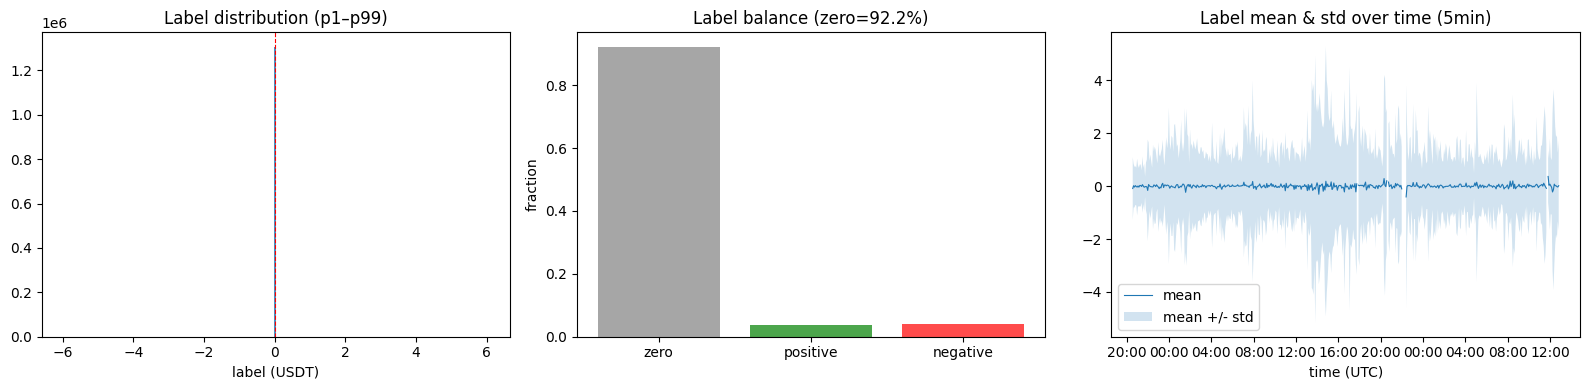

In [37]:
# --- Label distribution ---
if HAS_DS:
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    # Histogram
    ax = axes[0]
    lo, hi, tag = _qrange(label, 0.01, 0.99)
    ax.hist(label, bins=200, range=(lo, hi), edgecolor="none", alpha=0.8)
    ax.set_xlabel("label (USDT)")
    ax.set_title(f"Label distribution ({tag})")
    ax.axvline(0, color="red", ls="--", linewidth=0.8)

    # Zero / pos / neg
    ax = axes[1]
    ax.bar(["zero", "positive", "negative"], [zero_pct, pos_pct, neg_pct],
           color=["gray", "green", "red"], alpha=0.7)
    ax.set_ylabel("fraction")
    ax.set_title(f"Label balance (zero={zero_pct:.1%})")

    # Label over time
    ax = axes[2]
    lab_rs = ds.set_index("datetime")["label"].resample("5min")
    lab_mean = lab_rs.mean()
    lab_std = lab_rs.std()
    ax.plot(lab_mean.index, lab_mean, linewidth=0.8, label="mean")
    ax.fill_between(lab_mean.index, lab_mean - lab_std, lab_mean + lab_std,
                    alpha=0.2, label="mean +/- std")
    ax.set_title("Label mean & std over time (5min)")
    ax.legend()
    _fmt_xaxis(ax)

    fig.tight_layout()
    _save_fig(fig, "dataset_labels")
    plt.show()

In [38]:
# --- Dataset metrics by hour_of_day ---
if HAS_DS:
    ds["hour"] = ds["datetime"].dt.tz_convert(TIMEZONE).dt.hour
    dg = ds.groupby("hour")

    ds_hourly = pd.DataFrame({
        "row_count": dg["label"].count(),
        "label_mean (USDT)": dg["label"].mean(),
        "label_std (USDT)": dg["label"].std(),
        "label_pos_pct": dg["label"].apply(lambda x: (x > 0).mean()),
        "label_neg_pct": dg["label"].apply(lambda x: (x < 0).mean()),
        f"label_large_pct (>={ds_tick})": dg["label"].apply(lambda x: (x.abs() >= ds_tick).mean()),
        "avg_spread (USDT)": dg["spread"].mean(),
        "avg_imbalance_1": dg["imbalance_1"].mean(),
    })
    ds_hourly.index.name = "hour_of_day"

    print(f"=== Dataset Hourly Stats ({TIMEZONE}) ===")
    with pd.option_context("display.max_columns", 15, "display.width", 180, "display.float_format", "{:.6f}".format):
        print(ds_hourly.to_string())
    _save_csv(ds_hourly, "dataset_hourly_stats")

=== Dataset Hourly Stats (UTC) ===
             row_count  label_mean (USDT)  label_std (USDT)  label_pos_pct  label_neg_pct  label_large_pct (>=0.01)  avg_spread (USDT)  avg_imbalance_1
hour_of_day                                                                                                                                            
0                72000           0.001577          1.754737       0.041014       0.041194                  0.082181           0.011964        -0.024635
1                72000          -0.009061          1.752658       0.036167       0.035819                  0.071986           0.011654        -0.053484
2                72000          -0.005813          1.417757       0.028125       0.032708                  0.060833           0.010521        -0.056082
3                72000           0.007643          1.268635       0.023417       0.024778                  0.048194           0.010614        -0.019446
4                72000           0.002263          1.

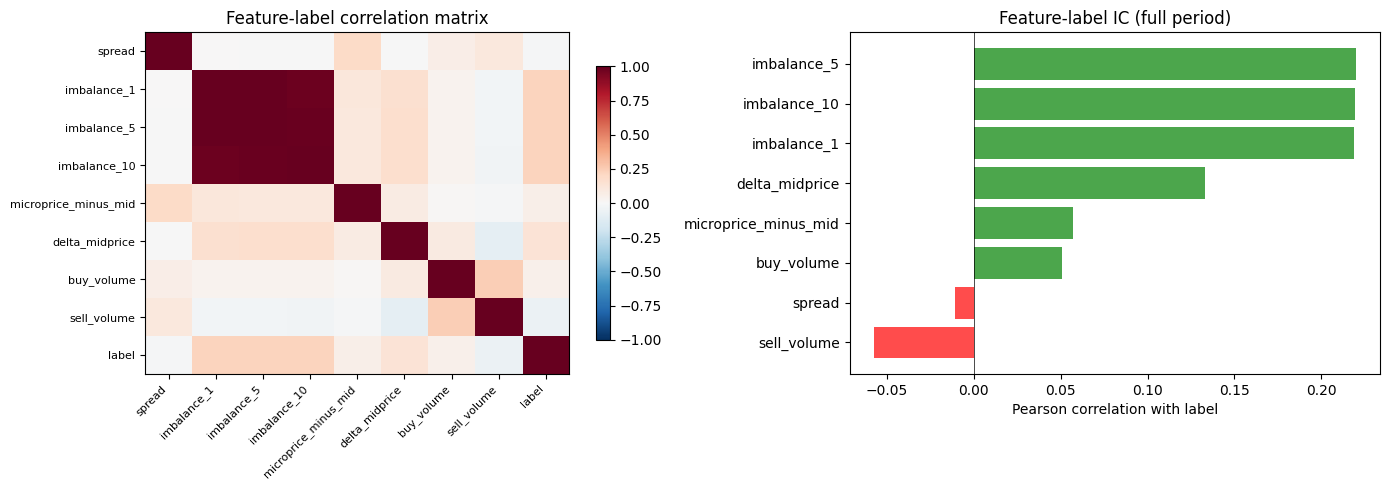


=== Feature-label Pearson correlation by hour ===
label  spread  imbalance_1  imbalance_5  imbalance_10  microprice_minus_mid  delta_midprice  buy_volume  sell_volume
hour                                                                                                                
0      0.0162       0.2198       0.2207        0.2217                0.0257          0.1616      0.0063      -0.0840
1     -0.0440       0.2030       0.2044        0.2048                0.0622          0.1189      0.0080      -0.0685
2     -0.0213       0.2069       0.2075        0.2071                0.1014          0.1265      0.0377      -0.0338
3      0.0002       0.1819       0.1825        0.1821                0.0920          0.1313      0.0596      -0.0307
4     -0.0346       0.1749       0.1761        0.1761                0.0387          0.1190      0.0594       0.0051
5      0.0559       0.1987       0.2001        0.1984                0.1087          0.1229      0.0672      -0.0321
6     -0.0112

In [39]:
# --- Feature-label relationships ---
if HAS_DS and features:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Correlation matrix
    ax = axes[0]
    corr = ds[features + ["label"]].corr()
    im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
    ax.set_xticks(range(len(corr)))
    ax.set_yticks(range(len(corr)))
    ax.set_xticklabels(corr.columns, rotation=45, ha="right", fontsize=8)
    ax.set_yticklabels(corr.columns, fontsize=8)
    fig.colorbar(im, ax=ax, shrink=0.8)
    ax.set_title("Feature-label correlation matrix")

    # IC bar chart
    ax = axes[1]
    ic = corr["label"].drop("label").sort_values()
    colors = ["green" if v > 0 else "red" for v in ic]
    ax.barh(ic.index, ic.values, color=colors, alpha=0.7)
    ax.set_xlabel("Pearson correlation with label")
    ax.set_title("Feature-label IC (full period)")
    ax.axvline(0, color="black", linewidth=0.5)

    fig.tight_layout()
    _save_fig(fig, "dataset_feature_label_corr")
    plt.show()

    # IC by hour
    print("\n=== Feature-label Pearson correlation by hour ===")
    ic_by_hour = ds.groupby("hour").apply(
        lambda g: g[features + ["label"]].corr()["label"].drop("label"),
        include_groups=False,
    )
    with pd.option_context("display.float_format", "{:.4f}".format, "display.width", 180):
        print(ic_by_hour.to_string())
    _save_csv(ic_by_hour, "feature_label_ic_by_hour")

---
## G. Save Summary

If `SAVE_OUTPUTS=True`, all tables and figures have been saved to `OUTPUT_DIR`.  
This cell writes a short text summary for quick reference.

In [40]:
if SAVE_OUTPUTS:
    lines = [f"Market Context Report: {SYMBOL}", "="*40, ""]
    lines.append(f"Generated from:")
    if HAS_RAW:
        lines.append(f"  Raw data: {RAW_DATA_PATH}")
    if HAS_DS:
        lines.append(f"  Dataset:  {DATASET_PATH}")
    lines.append(f"  Timezone: {TIMEZONE}")
    lines.append("")
    if book_df is not None and not book_df.empty:
        lines.append(f"Period: {book_df.datetime.min()} — {book_df.datetime.max()}")
        lines.append(f"Midprice: {book_df.midprice.iloc[0]:.2f} — {book_df.midprice.iloc[-1]:.2f} USDT")
        lines.append(f"Avg spread: {book_df.spread_ticks.mean():.2f} ticks ({book_df.spread_usd.mean():.4f} USDT)")
        lines.append(f"1-tick spread: {(book_df.spread_ticks == 1).mean():.1%}")
    if trades is not None and not trades.empty:
        lines.append(f"Trades: {len(trades):,}  Notional: ${trades.notional.sum():,.0f}")
    if HAS_DS:
        lines.append(f"\nDataset rows: {len(ds):,}")
        lines.append(f"Label mean: {ds.label.mean():.6f} USDT  std: {ds.label.std():.4f} USDT")
        lines.append(f"Label zero: {(ds.label == 0).mean():.1%}")
    lines.append("\n--- Files ---")
    for f in sorted(OUTPUT_DIR.glob("*")):
        lines.append(f"  {f.name}")
    txt = "\n".join(lines)
    (OUTPUT_DIR / "summary.txt").write_text(txt)
    print(txt)
else:
    print("SAVE_OUTPUTS=False — set to True and re-run to save artifacts.")

Market Context Report: BTCUSDT

Generated from:
  Raw data: ../data/raw/binance/BTCUSDT_v2
  Dataset:  ../data/datasets/binance/BTCUSDT_v2/dataset_v1.parquet
  Timezone: UTC

Period: 2026-03-23 20:27:35+00:00 — 2026-03-25 17:58:48+00:00
Midprice: 70784.13 — 70768.21 USDT
Avg spread: 1.16 ticks (0.0116 USDT)
1-tick spread: 99.9%
Trades: 7,166,719  Notional: $2,566,725,074

Dataset rows: 1,414,269
Label mean: 0.000465 USDT  std: 1.7752 USDT
Label zero: 92.2%

--- Files ---
  dataset_feature_label_corr.png
  dataset_features.png
  dataset_hourly_stats.csv
  dataset_labels.png
  dataset_summary.csv
  event_rates.png
  feature_label_ic_by_hour.csv
  hourly_profiles.png
  hourly_stats.csv
  microstructure_book.png
  microstructure_trades.png
  overview_book_1.png
  overview_book_2.png
  overview_trades.png
  summary.csv
  summary.txt
